In [36]:
#load relevant packages

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import joblib


#relevant packages for training a classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, make_scorer, f1_score

In [37]:
#create save file path
#base_directory='OneDrive - case.edu/Scott Lab/rna-seq/'
results_file ='combined_analyzed_Oct2025.h5ad'

In [38]:
#read in fused data and clean/format
adata_fus = sc.read_10x_mtx('fused/',
                           var_names='gene_symbols',
                           cache=True)
adata_fus.obs["sample"] = "fused"
barcodes = adata_fus.obs.index
modified_barcodes = [f"F_{barcode}" for barcode in barcodes]
adata_fus.obs.index = modified_barcodes
#adata_fus.obs

In [39]:
#read in parental data and clean/format
adata_par = sc.read_10x_mtx('parental/',
                           var_names='gene_symbols',
                           cache=True)
adata_par.obs["sample"]= "parental"
barcodes = adata_par.obs.index
modified_barcodes = [f"P_{barcode}" for barcode in barcodes]
adata_par.obs.index = modified_barcodes
#adata_par.obs

In [40]:
#read in resistant data and clean/format
adata_res = sc.read_10x_mtx('resistant/',
                           var_names='gene_symbols',
                           cache=True)
barcodes = adata_res.obs.index
modified_barcodes = [f"R_{barcode}" for barcode in barcodes]
adata_res.obs.index = modified_barcodes
adata_res.obs["sample"] = "resistant"
adata_res.obs

,sample
R_AAACCCAAGACGATAT-1,resistant
R_AAACCCAAGCCATATC-1,resistant
R_AAACCCAAGGTCGAGT-1,resistant
R_AAACCCAAGTTACGAA-1,resistant
R_AAACCCACACAGAGCA-1,resistant
...,...
R_TTTGGTTTCAGGACGA-1,resistant
R_TTTGGTTTCGGTGAAG-1,resistant
R_TTTGTTGAGATGGGCT-1,resistant
R_TTTGTTGAGCTGCCTG-1,resistant


In [41]:
#remove duplicates if any exist
adata_fus.var_names_make_unique()
adata_par.var_names_make_unique()
adata_res.var_names_make_unique()

print(adata_fus)
print(adata_par)
print(adata_res)

AnnData object with n_obs × n_vars = 6044 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 10353 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 8513 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'


In [42]:
#combine into one file/data structure before normalizing
adata_combined = ad.concat([adata_fus, adata_par, adata_res])
#note genes are no longer unique I hope that's okay? Should check with Arda

In [43]:
#QC: calculate mitochondrial expression levels
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True) #Calculate QC metrics

In [44]:
#filter for minimum genes/cell and minimum cells/gene
sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

In [45]:
#additional filtering for total counts, number of genes/cell, and percent mitochondrial genes
adata_combined_filtered = adata_combined[adata_combined.obs.total_counts<75000,:]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.n_genes >1000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.pct_counts_mt < 40, :]

In [46]:
#normalize and log counts
adata_combined_filtered = adata_combined_filtered.copy()
sc.pp.normalize_total(adata_combined_filtered, target_sum=1e6)
sc.pp.log1p(adata_combined_filtered)

In [48]:
#identify highly variable genes and regress out counts + mt genes
adata_combined_filtered = adata_combined_filtered.copy()
sc.pp.highly_variable_genes(adata_combined_filtered, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_combined_filtered = adata_combined_filtered[:, adata_combined_filtered.var.highly_variable]
adata_combined_filtered = adata_combined_filtered.copy()
sc.pp.regress_out(adata_combined_filtered, ['total_counts', 'pct_counts_mt'])
adata_combined_filtered = adata_combined_filtered.copy()
sc.pp.scale(adata_combined_filtered, max_value=10)

In [49]:
#save filtered combined data structure to results file
adata_combined_filtered.write_h5ad(results_file)

In [50]:
 sc.read_h5ad(results_file)

AnnData object with n_obs × n_vars = 24205 × 5933
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'

In [52]:
#Step 2: Extract feature matrix and labels
X = adata_combined_filtered.X
if hasattr(X, 'toarray'):
    X = X.toarray()
#print(X)
y = adata_combined_filtered.obs['sample'].values

#train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Optional: Select top features (genes) based on ANOVA F-value
k_best = 2000  # Number of top features to select
selector = SelectKBest(score_func=f_classif, k=k_best)

# Define cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42, )

# Without LDA
clf_rf = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('select', selector),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

clf_rf.fit(X_train, y_train)
scores_rf = cross_val_score(clf_rf, X_train, y_train, cv=cv)
print("Random Forest without LDA - Training Accuracy: %.3f ± %.3f" % (scores_rf.mean(), scores_rf.std()))

# With LDA (dimensionality reduction)
lda = LinearDiscriminantAnalysis()
clf_rf_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('select', selector),
    ('lda', lda),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
clf_rf_lda.fit(X_train, y_train)
scores_rf_lda = cross_val_score(clf_rf_lda, X_train, y_train, cv=cv)
print("Random Forest with LDA - Training Accuracy: %.3f ± %.3f" % (scores_rf_lda.mean(), scores_rf_lda.std()))

Random Forest without LDA - Training Accuracy: 0.917 ± 0.006
Random Forest with LDA - Training Accuracy: 0.951 ± 0.014


In [53]:

# Save the trained model to a file

joblib.dump(clf_rf, 'rf_fusion_classifier_model.pkl')
joblib.dump(clf_rf_lda, 'rf_lda_fusion_classifier_model.pkl')


['rf_lda_fusion_classifier_model.pkl']

In [ ]:
'''
# When reboot, load the model from the file

X = adata_combined_filtered.X
if hasattr(X, 'toarray'):
    X = X.toarray()
#print(X)
y = adata_combined_filtered.obs['sample'].values
#train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf_rf = joblib.load('rf_fusion_classifier_model.pkl')
clf_rf_lda = joblib.load('rf_lda_fusion_classifier_model.pkl')
'''


In [55]:
#visualize performance of both models
# Using UMAP for visualization
sc.tl.pca(adata_combined_filtered, svd_solver='arpack')
sc.pp.neighbors(adata_combined_filtered, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_combined_filtered)
#sc.pl.umap(adata_combined_filtered, color='sample')

'''
# Example: Fit models on training dataset
clf_rf.fit(X_train, y_train)
clf_rf_lda.fit(X_train, y_train)
'''

# Predict labels on test set
y_pred_rf = clf_rf.predict(X_test)
y_pred_rf_lda = clf_rf_lda.predict(X_test)





In [56]:
# Evaluate
print("RF Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Classification Report:\n", classification_report(y_test, y_pred_rf))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("RF + LDA Test Accuracy:", accuracy_score(y_test, y_pred_rf_lda))
print("RF + LDA Classification Report:\n", classification_report(y_test, y_pred_rf_lda))
print("RF + LDA Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_lda))


# Encode labels to integers
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
#print(y_encoded)
# Similarly for predictions
y_pred_rf_enc = le.transform(y_pred_rf)
y_pred_rf_lda_enc = le.transform(y_pred_rf_lda)

# Generate report as dict
report_dict_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_dict_rf_lda = classification_report(y_test, y_pred_rf_lda, output_dict=True)
# Convert to pandas DataFrame
report_df_rf = pd.DataFrame(report_dict_rf).transpose()
report_df_rf_lda = pd.DataFrame(report_dict_rf_lda).transpose()
# Optional: clean up or reformat
# For publication, you might want to format numbers
report_df_rf = report_df_rf.round(3)
report_df_rf_lda = report_df_rf_lda.round(3)
# Display the table
report_df_rf

RF Test Accuracy: 0.9148936170212766
RF Classification Report:
               precision    recall  f1-score   support

       fused       0.90      0.77      0.83      1161
    parental       0.91      0.96      0.94      2009
   resistant       0.93      0.96      0.94      1671

    accuracy                           0.91      4841
   macro avg       0.91      0.90      0.90      4841
weighted avg       0.91      0.91      0.91      4841

RF Confusion Matrix:
 [[ 898  152  111]
 [  69 1928   12]
 [  35   33 1603]]
RF + LDA Test Accuracy: 0.9458789506300351
RF + LDA Classification Report:
               precision    recall  f1-score   support

       fused       0.89      0.88      0.89      1161
    parental       0.95      0.95      0.95      2009
   resistant       0.98      0.98      0.98      1671

    accuracy                           0.95      4841
   macro avg       0.94      0.94      0.94      4841
weighted avg       0.95      0.95      0.95      4841

RF + LDA Confusion Ma

,precision,recall,f1-score,support
fused,0.896,0.773,0.830,1161.000
parental,0.912,0.960,0.935,2009.000
resistant,0.929,0.959,0.944,1671.000
accuracy,0.915,0.915,0.915,0.915
macro avg,0.912,0.897,0.903,4841.000
weighted avg,0.914,0.915,0.913,4841.000


In [57]:
report_df_rf_lda

,precision,recall,f1-score,support
fused,0.895,0.885,0.890,1161.000
parental,0.949,0.951,0.950,2009.000
resistant,0.977,0.983,0.980,1671.000
accuracy,0.946,0.946,0.946,0.946
macro avg,0.940,0.939,0.940,4841.000
weighted avg,0.946,0.946,0.946,4841.000


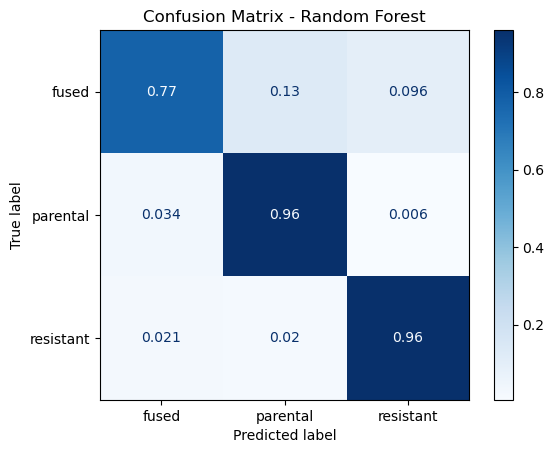

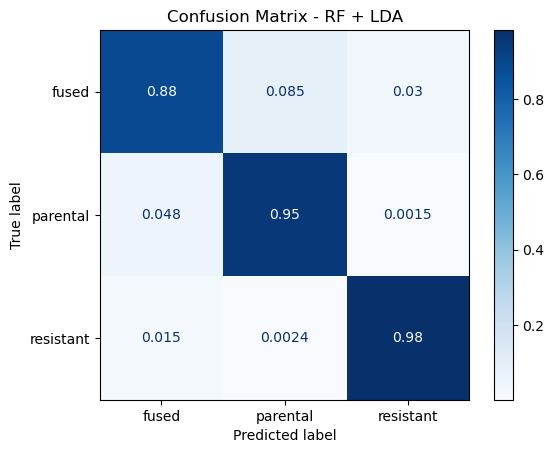

In [65]:
#confusion matrices
# Plot confusion matrix for RF
cm_rf = confusion_matrix(y_test_encoded, y_pred_rf_enc, normalize='true')
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
#plt.show()
plt.savefig("rf_confusion.png")

# Plot confusion matrix for RF+LDA
cm_rf_lda = confusion_matrix(y_test_encoded, y_pred_rf_lda_enc, normalize='true')
disp_rf_lda = ConfusionMatrixDisplay(confusion_matrix=cm_rf_lda, display_labels=le.classes_)
disp_rf_lda.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - RF + LDA")
#plt.show()
plt.savefig("rf_lda_confusion.png")

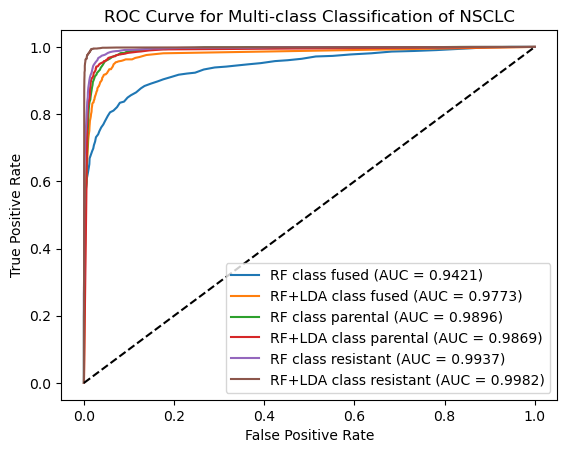

In [59]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_score_rf = clf_rf.predict_proba(X_test)
y_score_rf_lda = clf_rf_lda.predict_proba(X_test)

# For multi-class, you'll need to binarize labels
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize labels if multi-class
classes = np.unique(y_test)
y_bin = label_binarize(y_test, classes=classes)

# Compute ROC curve and AUC for each class
for i, class_name in enumerate(classes):
    fpr_rf, tpr_rf, _ = roc_curve(y_bin[:, i], y_score_rf[:, i])
    roc_auc_rf = roc_auc_score(y_bin[:, i], y_score_rf[:, i])

    fpr_lda, tpr_lda, _ = roc_curve(y_bin[:, i], y_score_rf_lda[:, i])
    roc_auc_lda = roc_auc_score(y_bin[:, i], y_score_rf_lda[:, i])

    plt.plot(fpr_rf, tpr_rf, label=f'RF class {class_name} (AUC = {roc_auc_rf:.4f})')
    plt.plot(fpr_lda, tpr_lda, label=f'RF+LDA class {class_name} (AUC = {roc_auc_lda:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class Classification of NSCLC')
plt.legend()
#plt.show()
plt.savefig("ROC_combined.png")


In [60]:
dict_res= {"rf": scores_rf, "rf+lda": scores_rf_lda}

# Prepare data for boxplot
categories = list(dict_res.keys())
values = list(dict_res.values())

# Plot
plt.figure(figsize=(8, 6))
plt.boxplot(values, patch_artist=True, tick_labels=categories)
plt.ylabel('F1-Score')
plt.title('Distribution of F1-Scores Across Cross-Validation Folds')
plt.show()
plt.savefig("F1_distribution_scores")

TypeError: boxplot() got an unexpected keyword argument 'tick_labels'

<Figure size 800x600 with 0 Axes>

In [ ]:
#make lda type umap plots

# Transform data using the LDA component
X_lda = clf_rf_lda.named_steps['lda'].transform(
    clf_rf_lda.named_steps['select'].transform(
        clf_rf_lda.named_steps['scaler'].transform(X)
    )
)

# Plot the 2D LDA projection
plt.figure(figsize=(8,6))
for label in np.unique(y):
    mask = y == label
    plt.scatter(X_lda[mask, 0], X_lda[mask, 1], label=label, alpha=0.7)
plt.xlabel('LDA Dimension 1')
plt.ylabel('LDA Dimension 2')
plt.title('Projection of Training Data to RF+LDA Classifier Feature Space ')
plt.legend()
#plt.show()
plt.savefig("LDA_proj.png")


In [100]:
#print(adata_combined_filtered.var_names)

# Get feature importances from RF
rf_importances = clf_rf['clf'].feature_importances_

print(len(rf_importances))
# Get LDA coefficients
lda_importances = clf_rf_lda['lda'].coef_[0]

print(clf_rf_lda.get_params())
# Assuming your pipeline step for ANOVA feature selection is named 'anova'
selector1 = clf_rf.named_steps['select']
selector2 = clf_rf_lda.named_steps['select']

# Get mask of selected features
selected_mask1 = selector1.get_support()
selected_mask2 = selector2.get_support()

# If input data was a DataFrame, get the feature names
selected_feature_names1 = adata_combined_filtered.var_names[selected_mask1]
selected_feature_names2 = adata_combined_filtered.var_names[selected_mask2]

overlap = selected_feature_names1.intersection(selected_feature_names2)

print(len(overlap)) #2000 so fully overlap!

print("Selected features for Rf:", selected_feature_names1)
print("Selected features for Rf_LDA:", selected_feature_names2)


2000
{'memory': None, 'steps': [('scaler', StandardScaler()), ('select', SelectKBest(k=2000)), ('lda', LinearDiscriminantAnalysis()), ('clf', RandomForestClassifier(random_state=42))], 'transform_input': None, 'verbose': False, 'scaler': StandardScaler(), 'select': SelectKBest(k=2000), 'lda': LinearDiscriminantAnalysis(), 'clf': RandomForestClassifier(random_state=42), 'scaler__copy': True, 'scaler__with_mean': True, 'scaler__with_std': True, 'select__k': 2000, 'select__score_func': <function f_classif at 0x16a334900>, 'lda__covariance_estimator': None, 'lda__n_components': None, 'lda__priors': None, 'lda__shrinkage': None, 'lda__solver': 'svd', 'lda__store_covariance': False, 'lda__tol': 0.0001, 'clf__bootstrap': True, 'clf__ccp_alpha': 0.0, 'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__max_leaf_nodes': None, 'clf__max_samples': None, 'clf__min_impurity_decrease': 0.0, 'clf__min_samples_leaf': 1, 'clf__min_samples_split

In [1]:
# Create a DataFrame for visualization

#print(len(selected_feature_names1))
#print(len(rf_importances))
#print(len(lda_importances))

features_df = pd.DataFrame({
    'feature': selected_feature_names1,
    'rf_importance': rf_importances,
    'lda_coeffs': lda_importances
})

# Rank features
features_df['combined_score'] = np.abs(features_df['rf_importance']) + np.abs(features_df['lda_coeffs'])
top_features = features_df.sort_values(by='combined_score', ascending=False)
features_filtered = top_features[top_features['combined_score'] >= 0.15]
print(features_filtered.shape)

# Plot top features
plt.figure(figsize=(10,6))
plt.barh(features_filtered['feature'], features_filtered['combined_score'])
plt.xlabel('Combined Importance Score')
plt.title('Top Performing Features with Combined Score >=0.15')
plt.gca().invert_yaxis()
plt.show()
plt.savefig("top_30_features_in_fusion_classifier.png")

# Display top N features
print(top_features.head(30))

NameError: name 'pd' is not defined

In [185]:
#gene set enrichment on all features from classifier

import gseapy as gp

# List of top gene features
all_genes = top_features['feature'].squeeze().str.strip().to_list()
#print(len(top_genes))

# Run GSEA or enrichment analysis
enr = gp.enrichr(gene_list=all_genes,
                 gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human'],
                 organism='Human',
                 outdir='enrichr_results',
                 cutoff=1.0)

# View results
print(enr.results.head())


               Gene_set                               Term Overlap   P-value  \
0  MSigDB_Hallmark_2020      TNF-alpha Signaling via NF-kB  28/200  0.042615   
1  MSigDB_Hallmark_2020                       Angiogenesis    7/36  0.062656   
2  MSigDB_Hallmark_2020  Epithelial Mesenchymal Transition  26/200  0.099350   
3  MSigDB_Hallmark_2020              Inflammatory Response  23/200  0.270183   
4  MSigDB_Hallmark_2020                            Hypoxia  21/200  0.440775   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.999996            0                     0    1.471720   
1          0.999996            0                     0    2.176532   
2          0.999996            0                     0    1.349369   
3          0.999996            0                     0    1.171463   
4          0.999996            0                     0    1.056459   

   Combined Score                                              Genes  
0        4.644075  TNC;TNFA

In [186]:
#gene set enrichment on top 30 features from classifer (combined score >=0.15)
# List of top gene features
top_genes = top_features['feature'][0:30].squeeze().str.strip().to_list()
#print(top_genes)
#print(top_genes.shape)

# Run GSEA or enrichment analysis
enr2 = gp.enrichr(gene_list=top_genes,
                 gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human'],
                 organism='Human',
                 outdir='enrichr_results',
                cutoff=1.0)

# View results
print(enr2.results.head())


               Gene_set               Term Overlap   P-value  \
0  MSigDB_Hallmark_2020    Mitotic Spindle   2/199  0.035703   
1  MSigDB_Hallmark_2020  KRAS Signaling Up   2/200  0.036031   
2  MSigDB_Hallmark_2020    Apical Junction   2/200  0.036031   
3  MSigDB_Hallmark_2020        Coagulation   1/138  0.187686   
4  MSigDB_Hallmark_2020          Apoptosis   1/161  0.215457   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.120103            0                     0    7.169326   
1          0.120103            0                     0    7.132756   
2          0.120103            0                     0    7.132756   
3          0.260462            0                     0    4.991946   
4          0.260462            0                     0    4.269397   

   Combined Score        Genes  
0       23.891833   PIF1;DOCK2  
1       23.704830   DOCK2;EREG  
2       23.704830  ADRA1B;MYL9  
3        8.351452          GDA  
4        6.553505         ERE

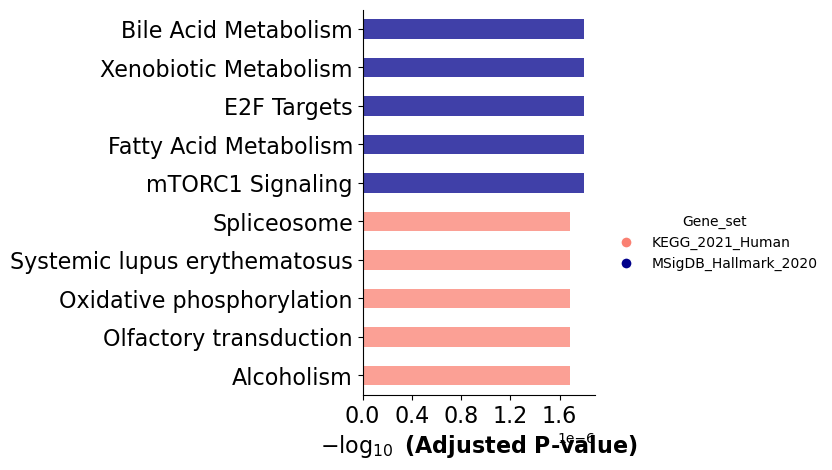

In [200]:
from gseapy import barplot, dotplot

# categorical barplot
ax = barplot(enr.results,
              column="Adjusted P-value",
              group='Gene_set', # set group, so you could do a multi-sample/library comparsion
              size=10,
              top_term=5,
              figsize=(3,5),
              #color=['darkred', 'darkblue'] # set colors for group
              color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'},
              cutoff= 2.0
             )



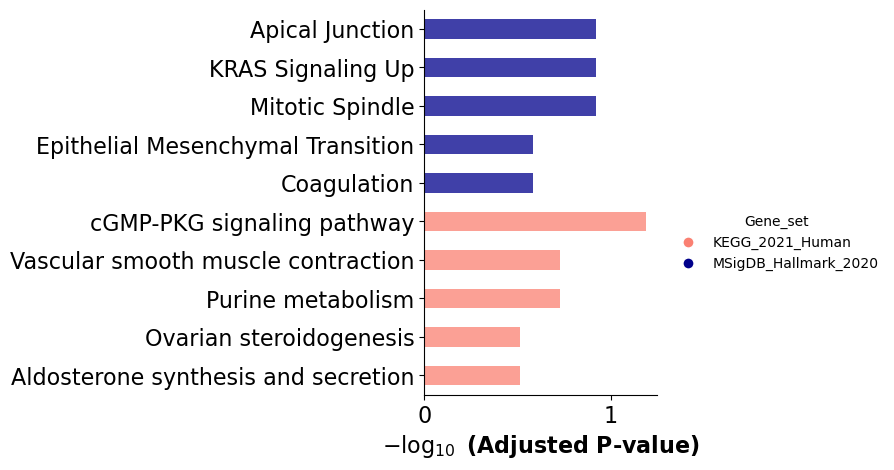

In [202]:
# categorical barplot
ax2 = barplot(enr2.results,
              column="Adjusted P-value",
              group='Gene_set', # set group, so you could do a multi-sample/library comparsion
              size=10,
              top_term=5,
              figsize=(3,5),
              #color=['darkred', 'darkblue'] # set colors for group
              color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'},
              cutoff = 2.0
             )